# XGBoost for our "numeric" dataset

### Note: I had to look all this up / ask an LLM for help.  I've added comments for what everything is doing at every step

In [ ]:
# this was done on colab

!pip install xgboost


In [1]:
import xgboost as xgb

# chatGPT typed this out so i didn't have to look it all up

# === Core ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt

# === Model Selection & Evaluation ===
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

# === Tree-Based Model ===
from sklearn.ensemble import RandomForestRegressor

# === Utility ===
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

In [2]:
url = "https://raw.githubusercontent.com/AHMerrill/housing-project/main/housing_data_numeric_NLP.csv"
# url = 'housing_data_numeric_NLP.csv'

housing_numeric_xg = pd.read_csv(url) # your transformed file name here
housing_numeric_xg['logLatestPrice'] = np.log(housing_numeric_xg['latestPrice'])
housing_numeric_xg

,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,...,zipcode78758,zipcode78759,log_lotSizeSqFt,log_livingAreaSqFt,log_avgSchoolSize,yearsOld_sq,avgSchoolRating_sq,word_count_good,word_count_bad,logLatestPrice
0,30.486408,-97.794724,2.21,0,True,False,False,False,687.850,40,...,0,0,9.275472,8.426174,7.138867,64,58.777778,2,0,6.533571
1,30.494375,-97.796516,2.21,2,True,True,False,True,409.000,31,...,0,0,9.111735,8.081475,7.301148,225,69.444444,1,1,6.013715
2,30.255707,-97.576958,1.98,2,False,True,False,False,199.000,21,...,0,0,8.915835,7.321189,7.299121,256,7.111111,0,1,5.293305
3,30.495638,-97.797874,2.21,0,True,False,False,False,400.000,20,...,0,0,8.944681,7.709308,7.301148,196,69.444444,2,0,5.991465
4,30.233154,-97.587318,1.98,2,False,True,False,False,240.000,10,...,0,0,8.553332,7.336286,7.284821,529,9.000000,0,0,5.480639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6779,30.329531,-97.738258,1.98,4,False,True,False,False,647.877,28,...,0,0,9.573302,7.711997,7.081709,324,49.000000,0,1,6.473701
6780,30.326372,-97.734268,1.98,1,False,True,False,False,445.000,28,...,0,0,8.849371,7.181592,7.081709,5329,49.000000,1,0,6.098074
6781,30.327656,-97.734779,1.98,1,False,True,False,False,400.000,22,...,0,0,9.212239,7.123673,7.081709,5041,49.000000,0,0,5.991465
6782,30.240223,-97.772835,1.98,2,True,True,True,True,550.000,32,...,0,0,7.799753,7.543803,7.112327,36,44.444444,1,0,6.309918


In [3]:
#from the sklearn documentation
housing_train, housing_test = train_test_split(housing_numeric_xg,test_size = .3, train_size = .7, random_state = 123, shuffle = True)


## XGBoost for latestPrice

In [4]:
# define the predictors and the target
predictors = housing_train.drop(columns = ['latestPrice','logLatestPrice'])
target = housing_train['latestPrice']

X_train = predictors
y_train = target

# define the regressor

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # loss function, ie. how it's optimizing
    random_state=123, # for reproducibility
    n_jobs=-1 # use all cores
)

param_grid = {
    'n_estimators': [100, 300], # number of boosting rounds (trees)
    'max_depth': [3, 6, 10], # max depth of trees
    'learning_rate': [0.1, 0.3], # learning rate (low is slow but accurate).  A learning rate is how much each tree or model iteration is allowed to change the final prediction
    'subsample': [0.7, 1.0], # what fraction of data each tree sees
    'colsample_bytree': [0.7, 1.0] # what fraction of features each tree sees
}

kfold = KFold(n_splits=5, shuffle=True, random_state=123)

# the grid search trains all combinations of the param_grid on every cv fold
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error', # higher is better, hence the sign switch
    n_jobs=-1,
    verbose=1,
    refit=True # finds the best fit and refits on the full training data
)

grid.fit(X_train, y_train) # fit it
best_xgb = grid.best_estimator_ # the final model is saved here


Fitting 5 folds for each of 48 candidates, totalling 240 fits


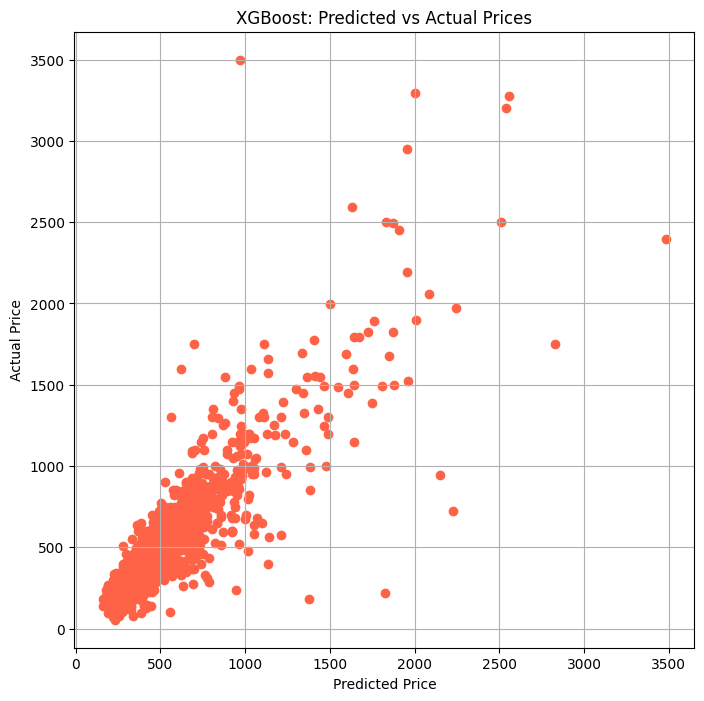

XGBoost Test RMSE: $159,254.48


In [5]:
# set up the test predictors
X_test = housing_test[predictors.columns]
y_test = housing_test['latestPrice']


y_pred = best_xgb.predict(X_test) # makes predictions on the test set

# Plot predicted vs actual - should be a straight line if it's perfect
plt.figure(figsize=(8, 8))
plt.scatter(y_pred, y_test, color='tomato')
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("XGBoost: Predicted vs Actual Prices")
plt.grid(True)
plt.show()

# Test MSE - out of sample MSE
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'XGBoost Test RMSE: ${xgb_test_rmse * 1000:,.02f}')



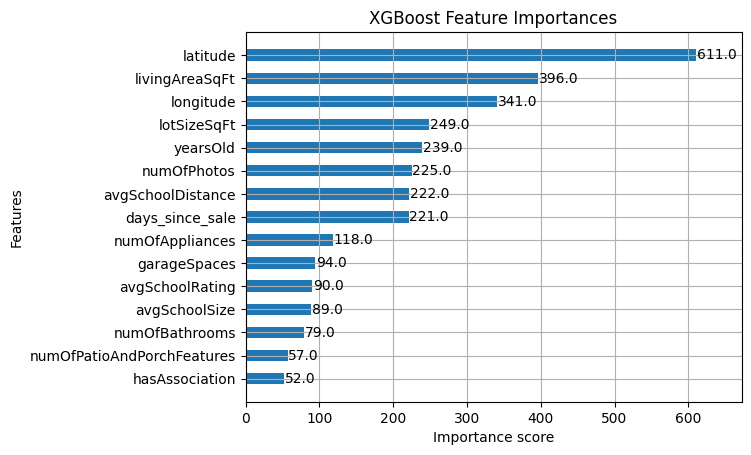

In [6]:
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importances")
plt.show()


## XG for logLatestPrice:

In [7]:
# again, I got chatGPT to do my variable swapping here so that logLatestPrice is the target

# define the predictors and the target
predictors = housing_train.drop(columns=['latestPrice', 'logLatestPrice'])
target = housing_train['logLatestPrice']  # log target now

X_train = predictors
y_train = target

# define the XGBoost regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # squared error loss for regression
    random_state=123,              # ensures reproducibility
    n_jobs=-1                      # use all available CPU cores
)

# hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 300],          # number of boosting rounds
    'max_depth': [3, 6, 10],             # depth of individual trees
    'learning_rate': [0.1, 0.3],         # step size shrinkage
    'subsample': [0.7, 1.0],             # fraction of samples for each tree
    'colsample_bytree': [0.7, 1.0]       # fraction of features for each tree
}

# cross-validation setup
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

# grid search for best combination of parameters
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

# train models and find best
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_


Fitting 5 folds for each of 48 candidates, totalling 240 fits


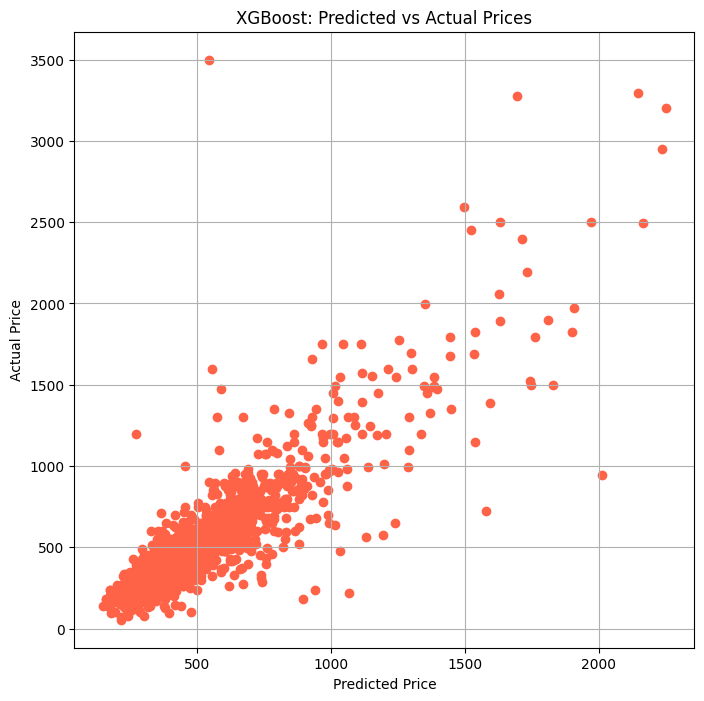

XGBoost Test RMSE: $158,733.39


In [9]:
# set up the test predictors
X_test = housing_test[predictors.columns]
y_test = housing_test['logLatestPrice']  # log-transformed target

# make predictions (still in log space)
y_pred = best_xgb.predict(X_test)

# Plot predicted vs actual (in price space)
plt.figure(figsize=(8, 8))
plt.scatter(np.exp(y_pred), np.exp(y_test), color='tomato')
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("XGBoost: Predicted vs Actual Prices")
plt.grid(True)
plt.show()

# Test MSE in dollar space
xgb_test_rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
print(f'XGBoost Test RMSE: ${xgb_test_rmse * 1000:,.02f}')


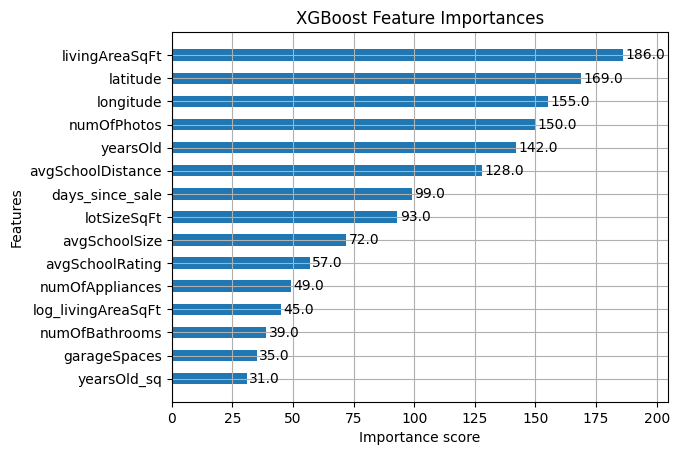

In [10]:
xgb.plot_importance(best_xgb, max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importances")
plt.show()